In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"]     = 120

print("Libraries loaded ✓")

Libraries loaded ✓


In [15]:
import pandas as pd

df = pd.read_csv(r"D:\Project File\ds-journey\StudentsPerformance.csv")

print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [16]:
print("=== Data types & nulls ===")
df.info()

print("\n=== Statistical summary ===")
df.describe().round(2)

=== Data types & nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

=== Statistical summary ===


,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [17]:
print("=== Missing values ===")
print(df.isna().sum())

print("\n=== Duplicates ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n=== Categorical value counts ===")
cat_cols = df.select_dtypes("object").columns
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


=== Missing values ===
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

=== Duplicates ===
Duplicate rows: 0

=== Categorical value counts ===

gender:
gender
female    518
male      482
Name: count, dtype: int64

race/ethnicity:
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

parental level of education:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

lunch:
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

test preparation course:
test preparation course
none         642
completed    358
Name: count, dtype: i

In [18]:
# Total and average score
df["total_score"]   = df["math score"] + df["reading score"] + df["writing score"]
df["average_score"] = (df["total_score"] / 3).round(2)

# Pass/fail (average >= 60)
df["passed"] = df["average_score"] >= 60

# Performance tier
conditions = [
    df["average_score"] >= 90,
    df["average_score"] >= 75,
    df["average_score"] >= 60,
]
choices = ["High", "Medium", "Low"]
df["performance"] = np.select(conditions, choices, default="At Risk")

print(df[["math score","reading score","writing score",
          "average_score","passed","performance"]].head(10))

print("\nPerformance distribution:")
print(df["performance"].value_counts())

   math score  reading score  writing score  average_score  passed performance
0          72             72             74          72.67    True         Low
1          69             90             88          82.33    True      Medium
2          90             95             93          92.67    True        High
3          47             57             44          49.33   False     At Risk
4          76             78             75          76.33    True      Medium
5          71             83             78          77.33    True      Medium
6          88             95             92          91.67    True        High
7          40             43             39          40.67   False     At Risk
8          64             64             67          65.00    True         Low
9          38             60             50          49.33   False     At Risk

Performance distribution:
performance
Low        391
At Risk    285
Medium     272
High        52
Name: count, dtype: int64


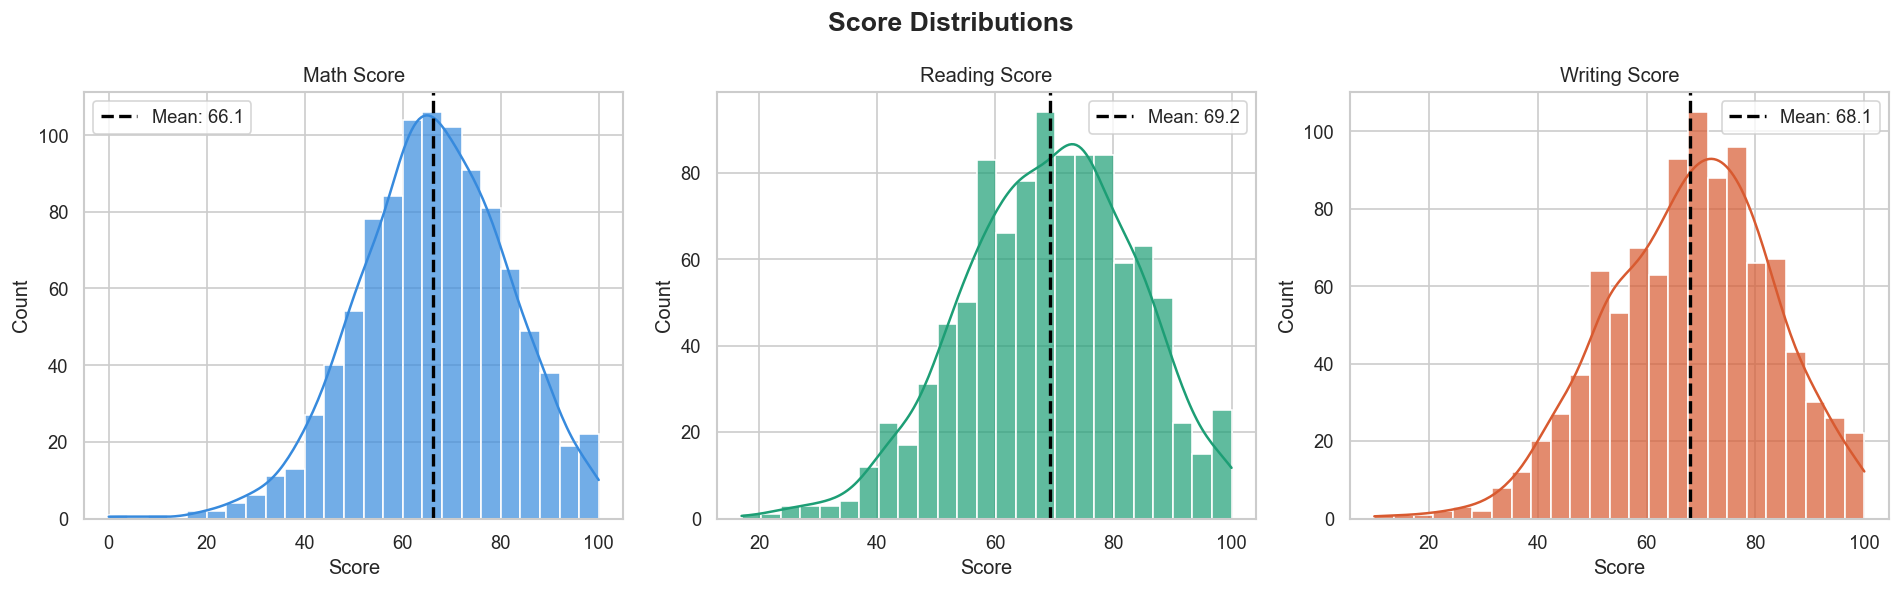

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Score Distributions", fontsize=16, fontweight="bold")

for ax, col, color in zip(axes,
    ["math score","reading score","writing score"],
    ["#378ADD","#1D9E75","#D85A30"]):

    sns.histplot(df[col], bins=25, kde=True,
                 color=color, alpha=0.7, ax=ax)
    ax.axvline(df[col].mean(), color="black",
               linewidth=2, linestyle="--",
               label=f"Mean: {df[col].mean():.1f}")
    ax.set_title(col.title())
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14752\3344307875.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="gender", y=col,
C:\Users\HP\AppData\Local\Temp\ipykernel_14752\3344307875.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="gender", y=col,
C:\Users\HP\AppData\Local\Temp\ipykernel_14752\3344307875.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df, x="gender", y=col,


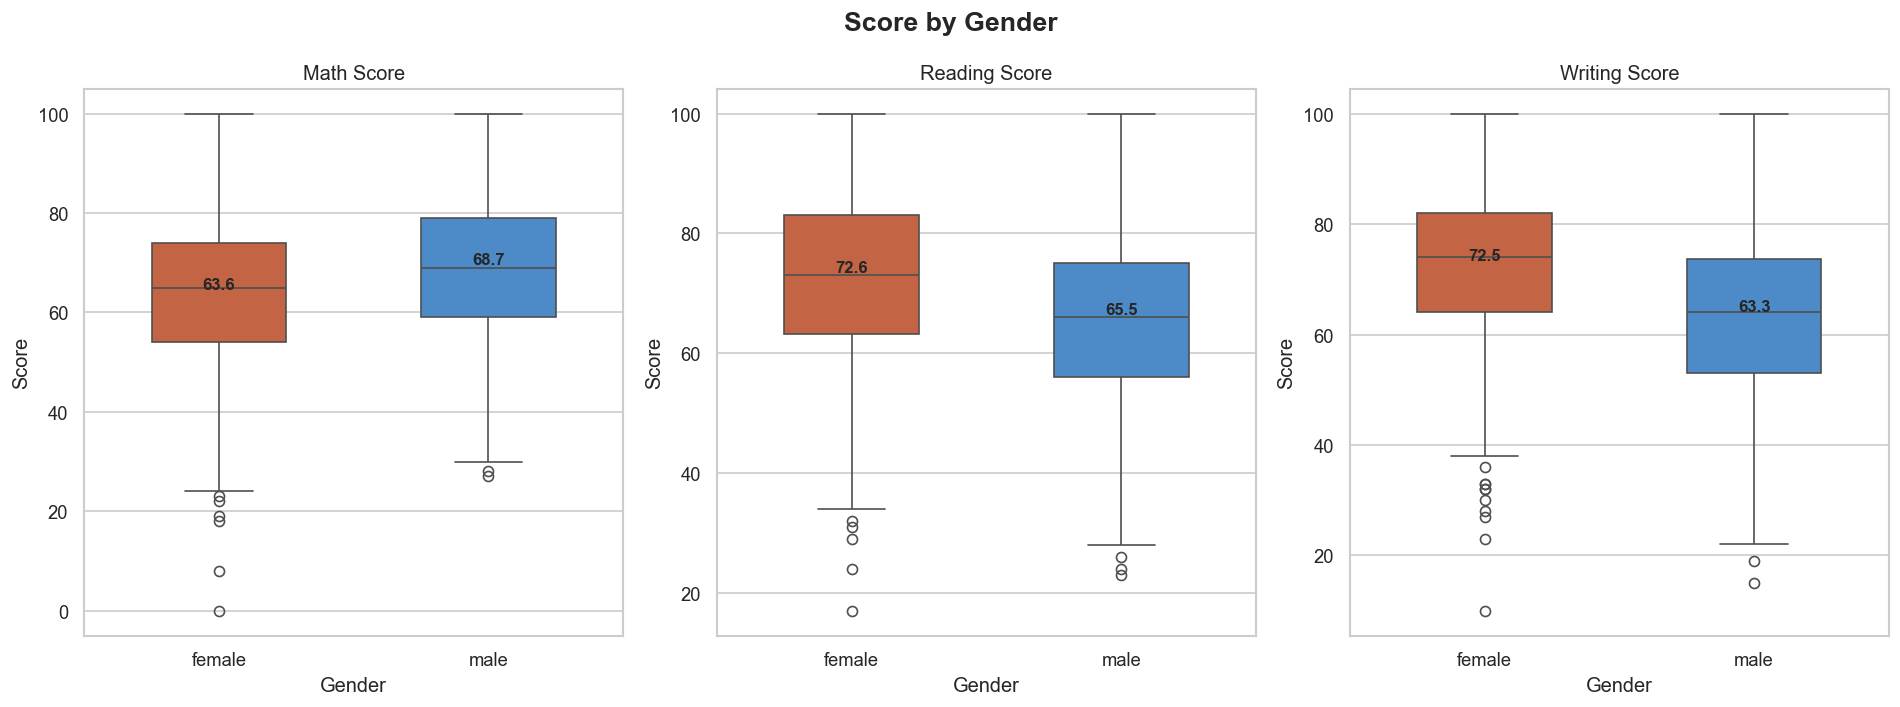

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Score by Gender", fontsize=16, fontweight="bold")

for ax, col in zip(axes, ["math score","reading score","writing score"]):
    sns.boxplot(df, x="gender", y=col,
                palette={"male":"#378ADD","female":"#D85A30"},
                ax=ax, width=0.5)
    # Add mean markers
    means = df.groupby("gender")[col].mean()
    for i, (gender, mean) in enumerate(means.items()):
        ax.text(i, mean + 1, f"{mean:.1f}",
                ha="center", fontweight="bold", fontsize=10)
    ax.set_title(col.title())
    ax.set_xlabel("Gender")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14752\1226130079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x="test preparation course", y=col,
C:\Users\HP\AppData\Local\Temp\ipykernel_14752\1226130079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x="test preparation course", y=col,
C:\Users\HP\AppData\Local\Temp\ipykernel_14752\1226130079.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x="test preparation course", y=col,


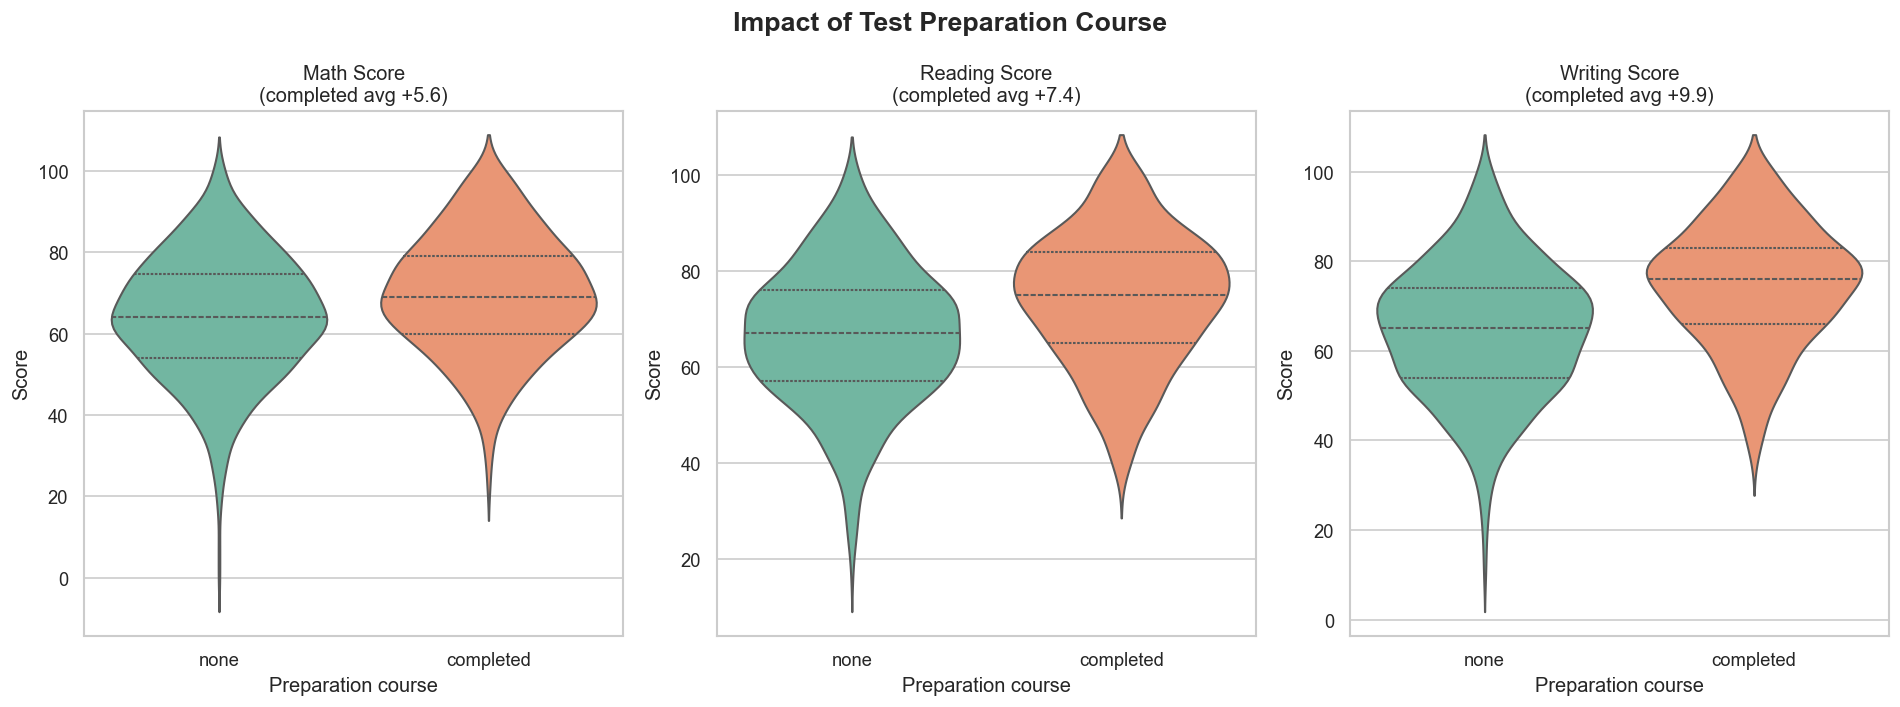

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Impact of Test Preparation Course", fontsize=16, fontweight="bold")

for ax, col in zip(axes, ["math score","reading score","writing score"]):
    sns.violinplot(df, x="test preparation course", y=col,
                   palette="Set2", inner="quartile", ax=ax)
    # Print difference
    means = df.groupby("test preparation course")[col].mean()
    diff  = means.get("completed", 0) - means.get("none", 0)
    ax.set_title(f"{col.title()}\n(completed avg {diff:+.1f})")
    ax.set_xlabel("Preparation course")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_14752\3110889970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x="lunch", y="average_score",
C:\Users\HP\AppData\Local\Temp\ipykernel_14752\3110889970.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x="average_score",


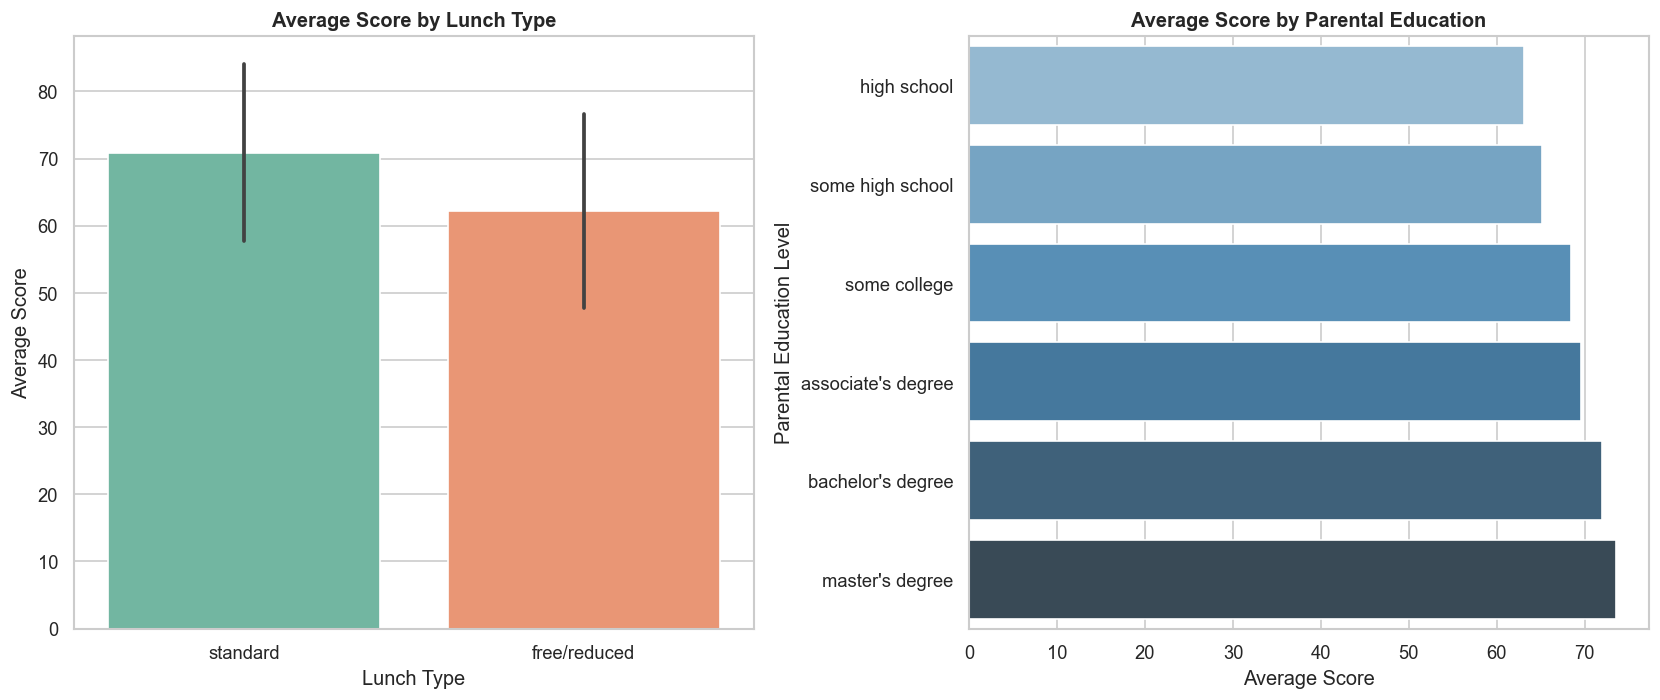

In [22]:
# Lunch type
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(df, x="lunch", y="average_score",
            palette="Set2", ax=axes[0], errorbar="sd")
axes[0].set_title("Average Score by Lunch Type", fontweight="bold")
axes[0].set_xlabel("Lunch Type")
axes[0].set_ylabel("Average Score")

# Parental education — sort by mean score
edu_order = (df.groupby("parental level of education")["average_score"]
               .mean()
               .sort_values()
               .index)
sns.barplot(df, x="average_score",
            y="parental level of education",
            order=edu_order, palette="Blues_d",
            ax=axes[1], errorbar=None)
axes[1].set_title("Average Score by Parental Education", fontweight="bold")
axes[1].set_xlabel("Average Score")
axes[1].set_ylabel("Parental Education Level")

plt.tight_layout()
plt.show()

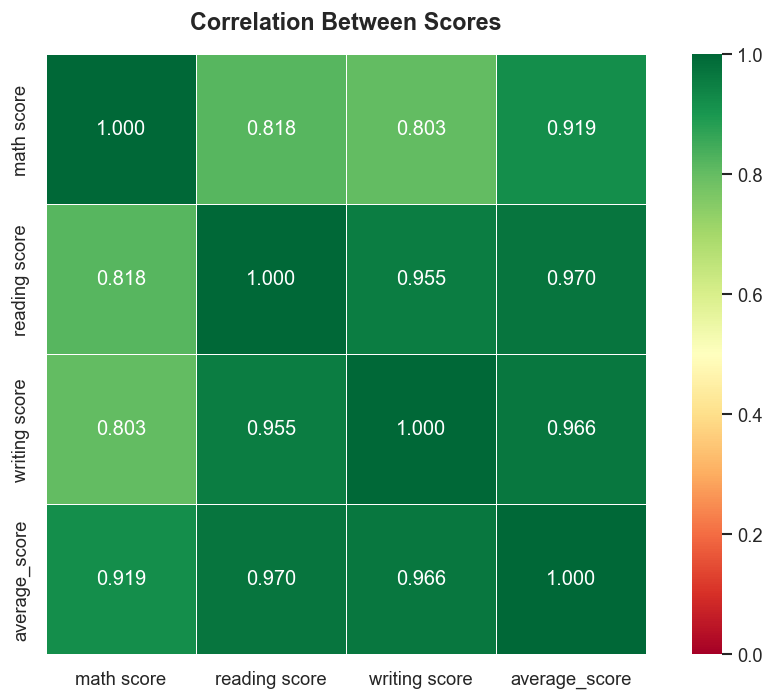

Strongest correlation: reading score & average_score: 0.970


In [23]:
corr = df[["math score","reading score",
            "writing score","average_score"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f",
            cmap="RdYlGn", vmin=0, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Between Scores",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# Print strongest correlation
mask = corr.where(~np.eye(len(corr), dtype=bool))
max_corr = mask.stack().idxmax()
print(f"Strongest correlation: {max_corr[0]} & {max_corr[1]}: {mask.loc[max_corr]:.3f}")

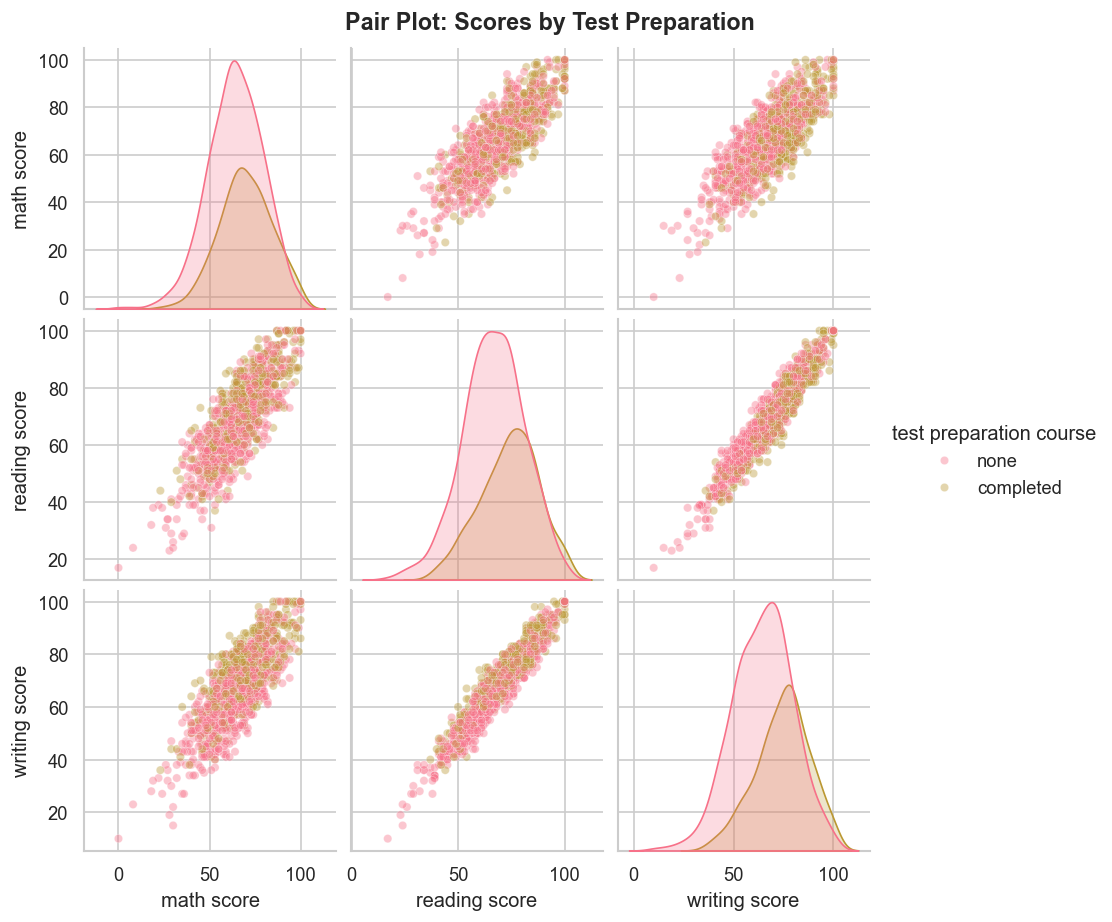

In [24]:
g = sns.pairplot(
    df[["math score","reading score","writing score","test preparation course"]],
    hue="test preparation course",
    diag_kind="kde",
    plot_kws={"alpha":0.4, "s":25},
    height=2.5
)
g.figure.suptitle("Pair Plot: Scores by Test Preparation",
                   y=1.02, fontsize=14, fontweight="bold")
plt.show()